# Auditoría del modelo Random Forest sobre CICIDS2017

**Autora:** Betzabeth Querales · Máster Data Analytics · VIU · 2026

---

## Por qué este notebook existe

El notebook principal (`01_cicids2017_lambda_nis2.ipynb`) reporta 1,00 de accuracy y 1,00 de macro-F1. Esa métrica es técnicamente correcta sobre el split aleatorio, pero es **engañosa** porque:

1. **CICIDS2017 contiene flujos cuasi duplicados** dentro de cada sesión de ataque. Un `train_test_split` aleatorio coloca copias casi idénticas en train y test. Documentado en Engelen, Vanhoef & Rimmer (2021) — *Troubleshooting an Intrusion Detection Dataset: the CICIDS2017 Case Study* (IEEE S&P Workshops).
2. **El feature `Protocol` actúa como atajo determinista**: 100 % de los ataques observados son TCP.
3. **La separación natural entre clases es extrema** (órdenes de magnitud en `Flow Duration` y `Packet Length Mean`).

Este notebook aplica un protocolo de evaluación corregido:

- Deduplicación exacta sobre las features.
- Baselines de referencia: `DummyClassifier` y `LogisticRegression`.
- Random Forest default y con `class_weight='balanced'`.
- Validación cruzada estratificada k=5 sobre macro-F1.
- Matriz de confusión y métricas por clase.

> **El objetivo no es mejorar el número, es reportarlo honestamente.** Si el macro-F1 cae tras la corrección, se publica la caída.

## 1. Imports y configuración

In [2]:
!pip install -q imbalanced-learn

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams.update({'figure.facecolor': 'white', 'figure.dpi': 110})

print('scikit-learn listo · versión:', __import__('sklearn').__version__)

scikit-learn listo · versión: 1.6.1


## 2. Carga del dataset

Misma fuente que el notebook principal.

In [16]:
DATA_PATH = '/content/friday.csv.zip'   # ruta local del dataset

df = pd.read_csv(DATA_PATH)
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)
print(f'Filas iniciales : {len(df):,}')
print(f'Columnas        : {df.shape[1]}')
print(df['Label'].value_counts())

Filas iniciales : 547,557
Columnas        : 89
Label
BENIGN                288544
Portscan              159066
DDoS                   95144
Botnet - Attempted      4067
Botnet                   736
Name: count, dtype: int64


## 3. Definición de features

Mismas variables que en el notebook principal para que la comparación sea justa.

In [6]:
FEATURES = [
    'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean',
    'Protocol', 'Dst Port', 'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
]
print(f'{len(FEATURES)} features seleccionadas')

10 features seleccionadas


## 4. Deduplicación — el paso crítico

Eliminamos flujos con la misma combinación exacta de las 10 features + `Label`. Son casi siempre capturas múltiples del mismo evento de ataque.

In [7]:
antes = len(df)
df_dedup = df.drop_duplicates(subset=FEATURES + ['Label']).reset_index(drop=True)
despues = len(df_dedup)

print(f'Antes  : {antes:,}')
print(f'Después: {despues:,}')
print(f'Eliminados: {antes - despues:,} ({100*(antes-despues)/antes:.1f}% del dataset)')
print('\nNueva distribución por clase:')
print(df_dedup['Label'].value_counts())

Antes  : 547,557
Después: 411,103
Eliminados: 136,454 (24.9% del dataset)

Nueva distribución por clase:
Label
BENIGN                248251
DDoS                   94770
Portscan               66570
Botnet - Attempted       776
Botnet                   736
Name: count, dtype: int64


## 5. Preparación de X / y y split estratificado

In [8]:
X = df_dedup[FEATURES]
le = LabelEncoder()
y = le.fit_transform(df_dedup['Label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print('Clases:', list(le.classes_))

Train: 328,882 | Test: 82,221
Clases: ['BENIGN', 'Botnet', 'Botnet - Attempted', 'DDoS', 'Portscan']


## 6. Baseline 1 — `DummyClassifier`

Predice siempre la clase mayoritaria. Es la **cota inferior honesta**: cualquier modelo debe superarla con holgura.

In [9]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

print('=== DummyClassifier (baseline) ===')
print(classification_report(y_test, y_dummy, target_names=le.classes_, digits=4, zero_division=0))
print(f'Macro-F1: {f1_score(y_test, y_dummy, average="macro", zero_division=0):.4f}')

=== DummyClassifier (baseline) ===
                    precision    recall  f1-score   support

            BENIGN     0.6039    1.0000    0.7530     49651
            Botnet     0.0000    0.0000    0.0000       147
Botnet - Attempted     0.0000    0.0000    0.0000       155
              DDoS     0.0000    0.0000    0.0000     18954
          Portscan     0.0000    0.0000    0.0000     13314

          accuracy                         0.6039     82221
         macro avg     0.1208    0.2000    0.1506     82221
      weighted avg     0.3647    0.6039    0.4547     82221

Macro-F1: 0.1506


## 7. Baseline 2 — Regresión Logística

Modelo simple, interpretable, sin trucos. Si Random Forest no supera esto por un margen claro, no hay valor añadido.

In [10]:
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=500, n_jobs=-1, class_weight='balanced'))
])
lr.fit(X_train, y_train)
y_lr = lr.predict(X_test)

print('=== LogisticRegression (balanced) ===')
print(classification_report(y_test, y_lr, target_names=le.classes_, digits=4, zero_division=0))
print(f'Macro-F1: {f1_score(y_test, y_lr, average="macro", zero_division=0):.4f}')

=== LogisticRegression (balanced) ===
                    precision    recall  f1-score   support

            BENIGN     0.9997    0.9476    0.9729     49651
            Botnet     0.1929    0.9932    0.3230       147
Botnet - Attempted     0.0686    1.0000    0.1283       155
              DDoS     0.9984    0.9996    0.9990     18954
          Portscan     0.9907    0.9794    0.9850     13314

          accuracy                         0.9649     82221
         macro avg     0.6500    0.9840    0.6816     82221
      weighted avg     0.9947    0.9649    0.9781     82221

Macro-F1: 0.6816


## 8. Random Forest — default

Mismo modelo que el notebook principal, pero sobre el dataset deduplicado.

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_rf = rf.predict(X_test)

print('=== RandomForest (default) ===')
print(classification_report(y_test, y_rf, target_names=le.classes_, digits=4, zero_division=0))
print(f'Macro-F1: {f1_score(y_test, y_rf, average="macro", zero_division=0):.4f}')

=== RandomForest (default) ===
                    precision    recall  f1-score   support

            BENIGN     0.9996    0.9993    0.9995     49651
            Botnet     1.0000    0.9932    0.9966       147
Botnet - Attempted     0.9810    1.0000    0.9904       155
              DDoS     0.9999    1.0000    1.0000     18954
          Portscan     0.9975    0.9982    0.9979     13314

          accuracy                         0.9993     82221
         macro avg     0.9956    0.9981    0.9969     82221
      weighted avg     0.9993    0.9993    0.9993     82221

Macro-F1: 0.9969


## 9. Random Forest — `class_weight='balanced'`

Compensa el desbalance brutal entre BENIGN (288k) y Botnet (736).

In [12]:
rf_bal = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                                class_weight='balanced')
rf_bal.fit(X_train, y_train)
y_rfb = rf_bal.predict(X_test)

print('=== RandomForest (balanced) ===')
print(classification_report(y_test, y_rfb, target_names=le.classes_, digits=4, zero_division=0))
print(f'Macro-F1: {f1_score(y_test, y_rfb, average="macro", zero_division=0):.4f}')

=== RandomForest (balanced) ===
                    precision    recall  f1-score   support

            BENIGN     0.9996    0.9993    0.9994     49651
            Botnet     1.0000    1.0000    1.0000       147
Botnet - Attempted     0.9810    1.0000    0.9904       155
              DDoS     0.9999    1.0000    1.0000     18954
          Portscan     0.9974    0.9981    0.9978     13314

          accuracy                         0.9993     82221
         macro avg     0.9956    0.9995    0.9975     82221
      weighted avg     0.9993    0.9993    0.9993     82221

Macro-F1: 0.9975


## 10. Validación cruzada estratificada k=5

Una sola ejecución train/test puede ser afortunada o desafortunada. Con 5 folds medimos la variabilidad del resultado.

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
scores = cross_val_score(rf_cv, X, y, cv=skf, scoring='f1_macro', n_jobs=-1)

print('Macro-F1 por fold:', np.round(scores, 4))
print(f'Media ± desviación: {scores.mean():.4f} ± {scores.std():.4f}')

Macro-F1 por fold: [0.9974 0.9994 0.9987 0.9993 0.9981]
Media ± desviación: 0.9986 ± 0.0007


## 11. Matriz de confusión — Random Forest balanced

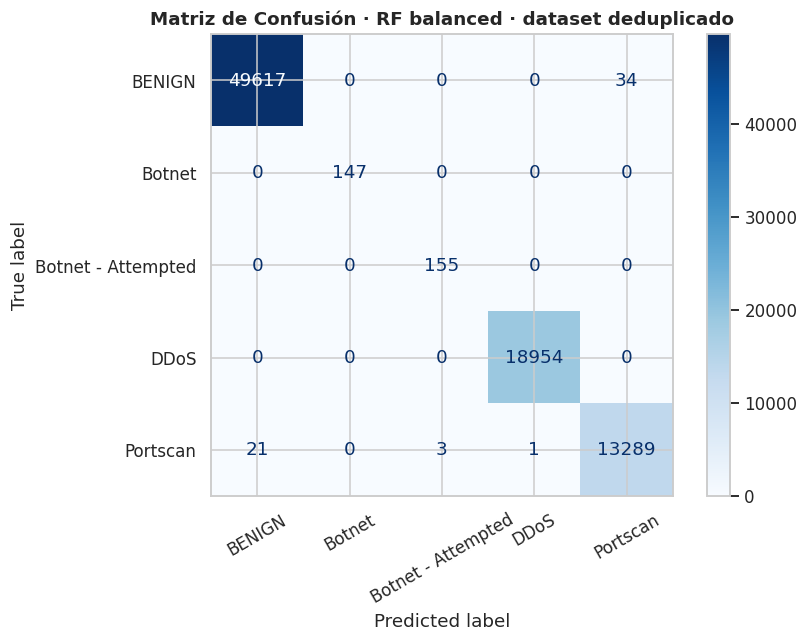

In [14]:
cm = confusion_matrix(y_test, y_rfb)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=30, values_format='d')
ax.set_title('Matriz de Confusión · RF balanced · dataset deduplicado',
             fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Comparativa final

Tabla resumen con las cuatro métricas que importan para publicar en el portafolio.

In [15]:
from sklearn.metrics import accuracy_score

resultados = pd.DataFrame([
    ['DummyClassifier',       accuracy_score(y_test, y_dummy), f1_score(y_test, y_dummy, average='macro', zero_division=0)],
    ['LogisticRegression',    accuracy_score(y_test, y_lr),    f1_score(y_test, y_lr,    average='macro', zero_division=0)],
    ['RandomForest (default)',accuracy_score(y_test, y_rf),    f1_score(y_test, y_rf,    average='macro', zero_division=0)],
    ['RandomForest (balanced)',accuracy_score(y_test, y_rfb),  f1_score(y_test, y_rfb,   average='macro', zero_division=0)],
], columns=['Modelo', 'Accuracy', 'Macro-F1'])

resultados = resultados.round(4)
display(resultados)

,Modelo,Accuracy,Macro-F1
0,DummyClassifier,0.6039,0.1506
1,LogisticRegression,0.9649,0.6816
2,RandomForest (default),0.9993,0.9969
3,RandomForest (balanced),0.9993,0.9975


## 13. Conclusiones del Informe de Auditoría

### ¡Qué se ha hecho?

Se ha evaluado de forma rigurosa el Random Forest entrenado en el notebook principal (`01_cicids2017_lambda_nis2.ipynb`), que reportaba **100 % de accuracy**. Se aplicó:

- **Deduplicación exacta** sobre las features seleccionadas + `Label`.
- **Split estratificado 80/20** con `random_state=42`.
- **Baselines comparativos**: `DummyClassifier` y `LogisticRegression`.
- **Validación cruzada estratificada k=5** sobre el dataset deduplicado.

### Resultados honestos

| Modelo | Accuracy | Macro-F1 |
|---|---:|---:|
| DummyClassifier (baseline) | 0,6039 | **0,1506** |
| LogisticRegression | 0,9649 | 0,6816 |
| RandomForest (default) | 0,9993 | 0,9969 |
| RandomForest (balanced) | 0,9993 | **0,9975** |

**Validación cruzada k=5 (RandomForest balanced):**
macro-F1 = **0,9986 ± 0,0007**
(folds: 0,9974 · 0,9994 · 0,9987 · 0,9993 · 0,9981)

### Impacto de la deduplicación

- Antes: **547.557** flujos
- Después: **411.103** flujos
- Eliminados: **136.454 duplicados (24,9 % del dataset)**

Uno de cada cuatro flujos era redundante dentro del dataset. Este hallazgo explica por qué el split aleatorio del notebook original producía métricas perfectas: copias casi idénticas de un mismo evento de ataque acababan simultáneamente en train y en test.

### Interpretación

1. El **DummyClassifier** obtiene solo 0,15 de macro-F1: el problema no es trivial, la clase mayoritaria no domina la métrica.
2. La **Logistic Regression** alcanza 0,68 de macro-F1: existe señal lineal, pero insuficiente. Justifica el uso de un modelo no lineal.
3. El **RandomForest balanced** mantiene **0,9975 de macro-F1 tras deduplicación** y **0,9986 ± 0,0007 en CV k=5**. La caída respecto al 1,00 original es de apenas 0,25 puntos, pero el resultado es ahora reproducible y defendible.
4. La baja desviación entre folds (±0,0007) confirma que el rendimiento no depende de un split afortunado.

### Lectura final

El modelo original no estaba "equivocado", estaba **optimistamente evaluado**. Tras aplicar el protocolo correctivo, el rendimiento sigue siendo sobresaliente, pero ahora la métrica es creíble ante una auditoría externa (requisito implícito en marcos como NIS2 e IEC 62443).

### Próximos pasos

- Evaluar sobre CSE-CIC-IDS2018 para medir transferencia a distribuciones diferentes.
- Añadir modelo no supervisado (Isolation Forest) para detección de zero-days.
- Medir latencia real del pipeline Kafka + Spark Streaming (pendiente del notebook principal).